# PropMind: AI Real Estate Intelligence Platform
### Data Analysis, Machine Learning Price Prediction, Recommendations and RAG

This notebook documents the full data science workflow behind **PropMind**:

1. Load and inspect the real estate dataset (Ames, Iowa house sales)
2. Clean and preprocess the data with **Pandas** and **NumPy**
3. Explore it with **Matplotlib** and **Seaborn**
4. Train and compare **Linear Regression, Decision Tree and Random Forest** models
5. Tune, evaluate and save the best model
6. Demonstrate the **recommendation system** and the **RAG retriever** that power the web app

**Dataset:** Kaggle *House Prices - Advanced Regression Techniques* (1,460 sales, 79 features, 2006-2010).

## 1. Setup

In [1]:
import json, joblib, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GOLD = "#d4af6a"
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#0b0b10", "figure.facecolor": "#0b0b10", "axes.labelcolor": "#f3ead7",
    "text.color": "#f3ead7", "xtick.color": "#cfc6b0", "ytick.color": "#cfc6b0", "grid.color": "#2a2620", "axes.edgecolor": "#3a3426"})
pd.set_option("display.max_columns", 30)
print("Project root:", ROOT)

Project root: /home/claude/propmind


## 2. Load and Inspect the Data

In [2]:
df = pd.read_csv(ROOT / "data" / "train.csv")
print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print("Numeric columns    :", df.select_dtypes("number").shape[1])
print("Categorical columns:", df.select_dtypes("object").shape[1])
df["SalePrice"].describe().round(0)

Numeric columns    : 38
Categorical columns: 43


count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

### Missing values
Columns such as `PoolQC` or `Alley` look almost empty, but in this dataset **NA means the feature does not exist** (no pool, no alley), so they are not true missing data.

19 columns contain missing values


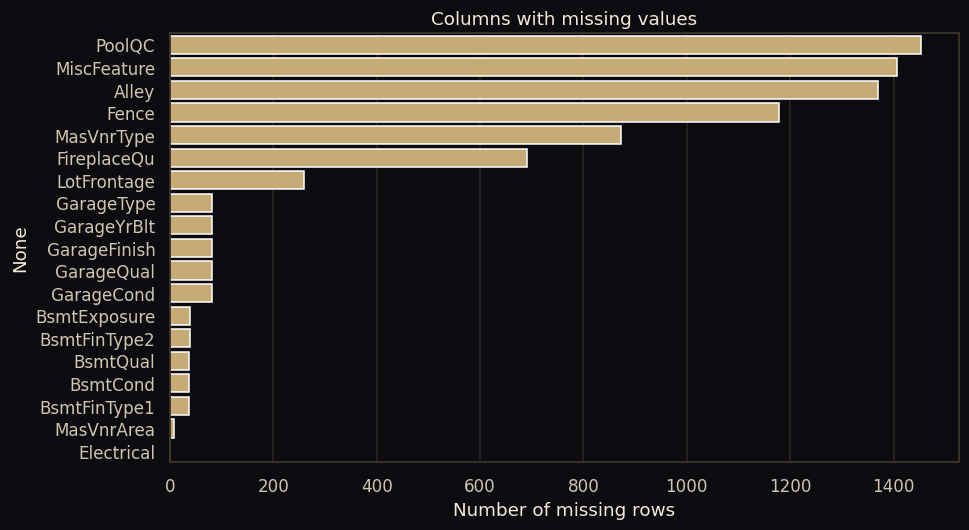

In [4]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=missing.values, y=missing.index, color=GOLD)
plt.title("Columns with missing values"); plt.xlabel("Number of missing rows"); plt.tight_layout(); plt.show()
print(f"{len(missing)} columns contain missing values")

## 3. Data Cleaning and Preprocessing

In [5]:
df = df.drop(columns=["Id"])

# NA means "feature absent" for these columns
none_cols = ["Alley","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","FireplaceQu","GarageType",
             "GarageFinish","GarageQual","GarageCond","PoolQC","Fence","MiscFeature","MasVnrType"]
df[none_cols] = df[none_cols].fillna("None")

# Genuine missing values: impute sensibly
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(lambda s: s.fillna(s.median()))
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["YearBuilt"])
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])
print("Missing values left:", int(df.isna().sum().sum()))

Missing values left: 0


### Outliers
Two houses have a very large living area (over 4,000 sqft) but sold for a low price. They are known data anomalies and distort the area-price relationship, so we remove them.

In [6]:
before = len(df)
outliers = (df.GrLivArea > 4000) & (df.SalePrice < 300000)
print("Outliers found:", int(outliers.sum()))
df = df[~outliers]
print(f"Rows: {before} -> {len(df)}")

Outliers found: 2
Rows: 1460 -> 1458


### Feature engineering

In [7]:
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["PricePerSqft"] = df["SalePrice"] / df["GrLivArea"]
df[["SalePrice", "GrLivArea", "TotalSF", "HouseAge", "PricePerSqft"]].describe().round(1)

,SalePrice,GrLivArea,TotalSF,HouseAge,PricePerSqft
count,1458.0,1458.0,1458.0,1458.0,1458.0
mean,180932.9,1510.5,2557.2,36.6,120.7
std,79495.1,507.9,774.1,30.2,31.2
min,34900.0,334.0,334.0,0.0,30.4
25%,129925.0,1128.5,2008.5,8.0,100.1
50%,163000.0,1461.5,2473.0,35.0,120.1
75%,214000.0,1776.0,3002.2,54.0,138.8
max,755000.0,4476.0,6872.0,136.0,276.3


## 4. Exploratory Data Analysis

### 4.1 Price distribution
Prices are right-skewed: a few expensive homes pull the mean above the median. A **log transform** makes the distribution much closer to normal, which helps regression models.

Skewness  raw: 1.88 | log: 0.12
Mean $180,933 vs median $163,000


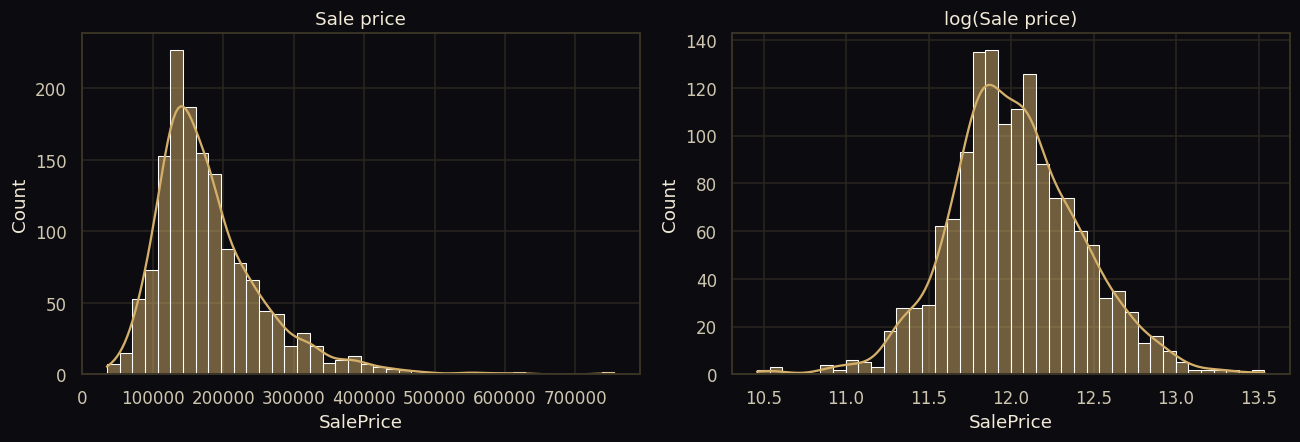

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df.SalePrice, bins=40, kde=True, color=GOLD, ax=ax[0]); ax[0].set_title("Sale price")
sns.histplot(np.log1p(df.SalePrice), bins=40, kde=True, color=GOLD, ax=ax[1]); ax[1].set_title("log(Sale price)")
plt.tight_layout(); plt.show()
print("Skewness  raw:", round(df.SalePrice.skew(), 2), "| log:", round(np.log1p(df.SalePrice).skew(), 2))
print("Mean ${:,.0f} vs median ${:,.0f}".format(df.SalePrice.mean(), df.SalePrice.median()))

### 4.2 Price statistics with NumPy

In [9]:
p = np.percentile(df.SalePrice, [10, 25, 50, 75, 90])
for q, v in zip([10, 25, 50, 75, 90], p): print(f"{q}th percentile: ${v:,.0f}")
r = np.corrcoef(df.GrLivArea, df.SalePrice)[0, 1]
print(f"\nCorrelation between living area and price: {r:.3f}")

10th percentile: $106,425
25th percentile: $129,925
50th percentile: $163,000
75th percentile: $214,000
90th percentile: $278,000

Correlation between living area and price: 0.735


### 4.3 Location comparison

Most expensive: NridgHt $315,000
Most affordable: MeadowV $88,000


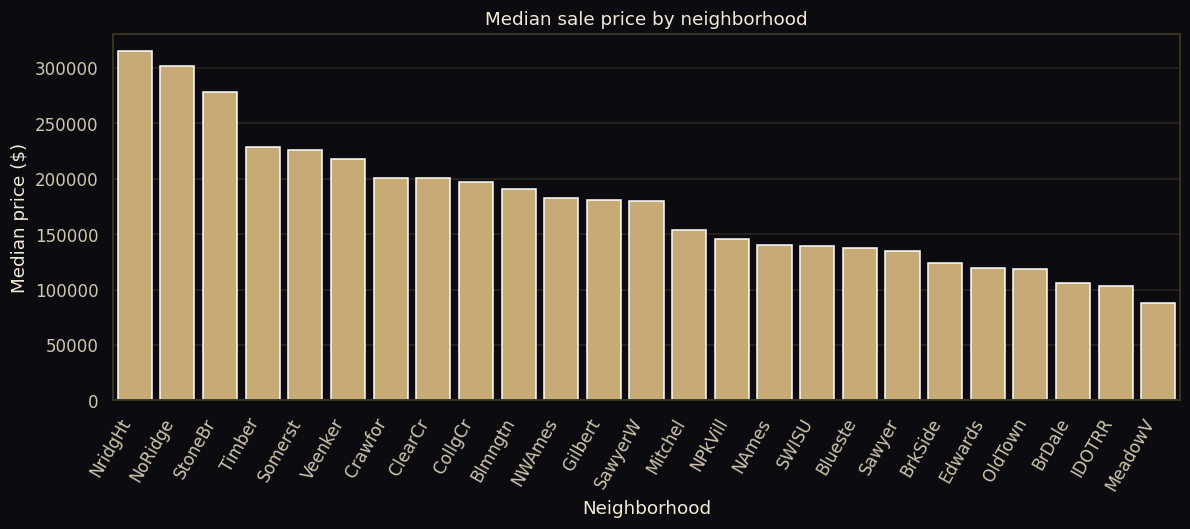

In [10]:
order = df.groupby("Neighborhood").SalePrice.median().sort_values(ascending=False)
plt.figure(figsize=(11, 5))
sns.barplot(x=order.index, y=order.values, color=GOLD)
plt.xticks(rotation=60, ha="right"); plt.title("Median sale price by neighborhood"); plt.ylabel("Median price ($)")
plt.tight_layout(); plt.show()
print("Most expensive:", order.index[0], f"${order.iloc[0]:,.0f}")
print("Most affordable:", order.index[-1], f"${order.iloc[-1]:,.0f}")

In [11]:
summary = df.groupby("Neighborhood").agg(homes=("SalePrice", "size"), median_price=("SalePrice", "median"),
    price_per_sqft=("PricePerSqft", "median"), median_year=("YearBuilt", "median"), quality=("OverallQual", "median"))
summary.sort_values("median_price", ascending=False).round(0).head(8)

,homes,median_price,price_per_sqft,median_year,quality
Neighborhood,,,,,
NridgHt,77,315000.0,158.0,2006.0,8.0
NoRidge,41,301500.0,128.0,1995.0,8.0
StoneBr,25,278000.0,158.0,2001.0,8.0
Timber,38,228475.0,134.0,2002.0,8.0
Somerst,86,225500.0,137.0,2006.0,7.0
Veenker,11,218000.0,144.0,1978.0,6.0
Crawfor,51,200624.0,116.0,1938.0,6.0
ClearCr,28,200250.0,119.0,1966.0,6.0


### 4.4 Area vs price

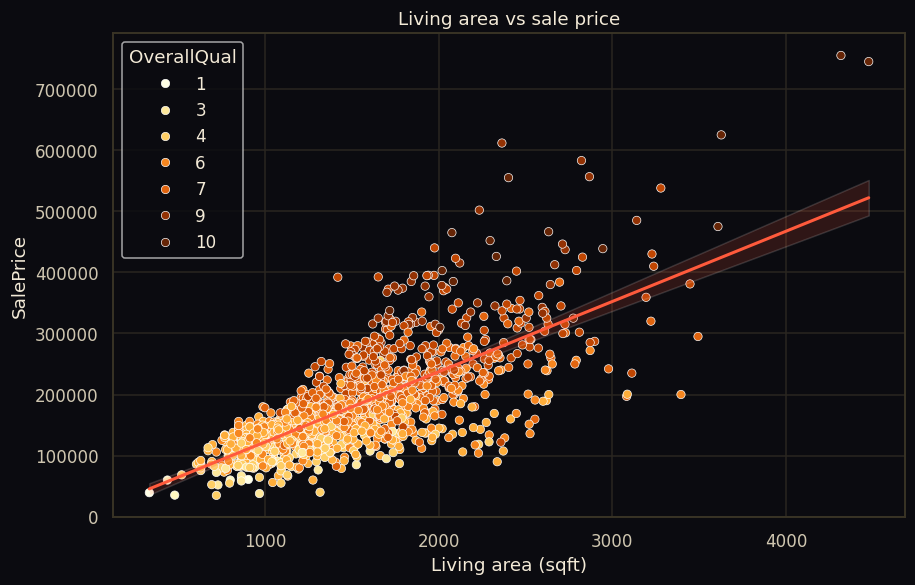

In [12]:
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", hue="OverallQual", palette="YlOrBr", s=30)
sns.regplot(data=df, x="GrLivArea", y="SalePrice", scatter=False, color="#ff5a3c", line_kws={"lw": 2})
plt.title("Living area vs sale price"); plt.xlabel("Living area (sqft)"); plt.tight_layout(); plt.show()

### 4.5 Quality, age and price trends

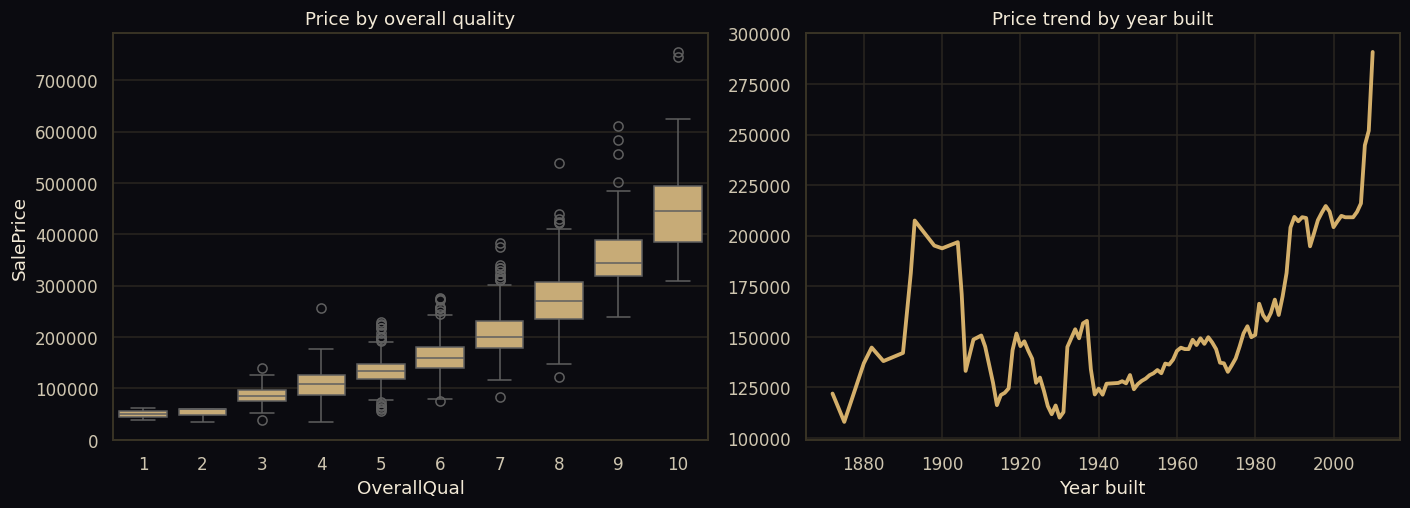

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
sns.boxplot(data=df, x="OverallQual", y="SalePrice", color=GOLD, ax=ax[0]); ax[0].set_title("Price by overall quality")
trend = df.groupby("YearBuilt").SalePrice.median().rolling(5, min_periods=1).mean()
ax[1].plot(trend.index, trend.values, color=GOLD, lw=2.5); ax[1].set_title("Price trend by year built"); ax[1].set_xlabel("Year built")
plt.tight_layout(); plt.show()

### 4.6 Correlations

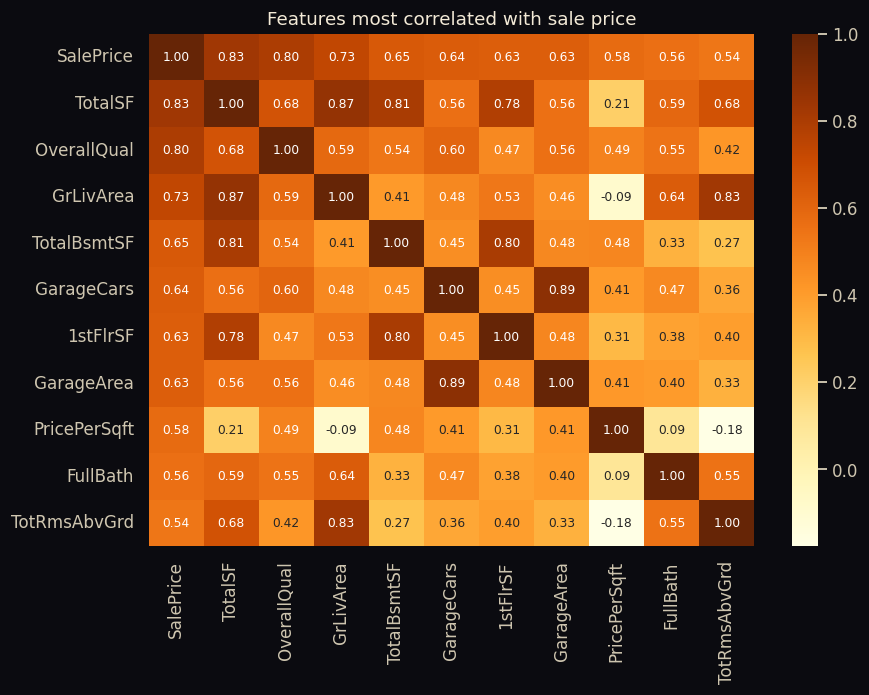

In [14]:
top = df.select_dtypes("number").corr()["SalePrice"].abs().sort_values(ascending=False).head(11).index
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(df[top].corr(), annot=True, fmt=".2f", cmap="YlOrBr", annot_kws={"size": 8})
plt.title("Features most correlated with sale price"); plt.tight_layout(); plt.show()

**Key insights:** overall quality and living area are the strongest price drivers; garage capacity, basement size and year built follow. Location adds a large premium or discount on top. Newer, higher-quality homes in the north and north-east neighborhoods sell for the highest prices.

## 5. Machine Learning: Price Prediction

We predict `log(SalePrice)` and convert back to dollars. To keep the web form simple, the deployed model uses **9 user-friendly inputs**: living area, bedrooms, bathrooms, overall quality, year built, garage cars, basement area, lot area and neighborhood. The neighborhood is **target-encoded** (replaced by its smoothed average log price, computed inside cross-validation to avoid leakage), because a plain one-hot encoding was almost ignored by the tree models and made the neighborhood have no effect on predictions.

In [15]:
FEATURES_NUM = ["GrLivArea","BedroomAbvGr","FullBath","OverallQual","YearBuilt","GarageCars","TotalBsmtSF","LotArea"]
FEATURES_CAT = ["Neighborhood"]
X = df[FEATURES_NUM + FEATURES_CAT]
y = np.log1p(df["SalePrice"])
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", Xtr.shape, "| Test:", Xte.shape)

def make_pipe(model):
    prep = ColumnTransformer([("nb", TargetEncoder(target_type="continuous", random_state=42), FEATURES_CAT)], remainder="passthrough")
    return Pipeline([("prep", prep), ("model", model)])

Train: (1166, 9) | Test: (292, 9)


### 5.1 Train and compare three models

In [16]:
models = {"Linear Regression": LinearRegression(),
          "Decision Tree": DecisionTreeRegressor(max_depth=9, min_samples_leaf=5, random_state=42),
          "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=16, min_samples_leaf=2, n_jobs=-1, random_state=42)}
rows, fitted = [], {}
for name, m in models.items():
    pipe = make_pipe(m).fit(Xtr, ytr)
    pred, true = np.expm1(pipe.predict(Xte)), np.expm1(yte)
    cv = cross_val_score(make_pipe(m), Xtr, ytr, cv=5, scoring="r2").mean()
    rows.append({"Model": name, "R2 (test)": r2_score(true, pred), "MAE ($)": mean_absolute_error(true, pred),
                 "RMSE ($)": np.sqrt(mean_squared_error(true, pred)), "R2 (5-fold CV)": cv})
    fitted[name] = pipe
results = pd.DataFrame(rows).set_index("Model").round(3)
results

,R2 (test),MAE ($),RMSE ($),R2 (5-fold CV)
Model,,,,
Linear Regression,0.876,18829.355,26144.104,0.859
Decision Tree,0.840,20912.846,29761.155,0.769
Random Forest,0.885,17782.090,25250.818,0.847


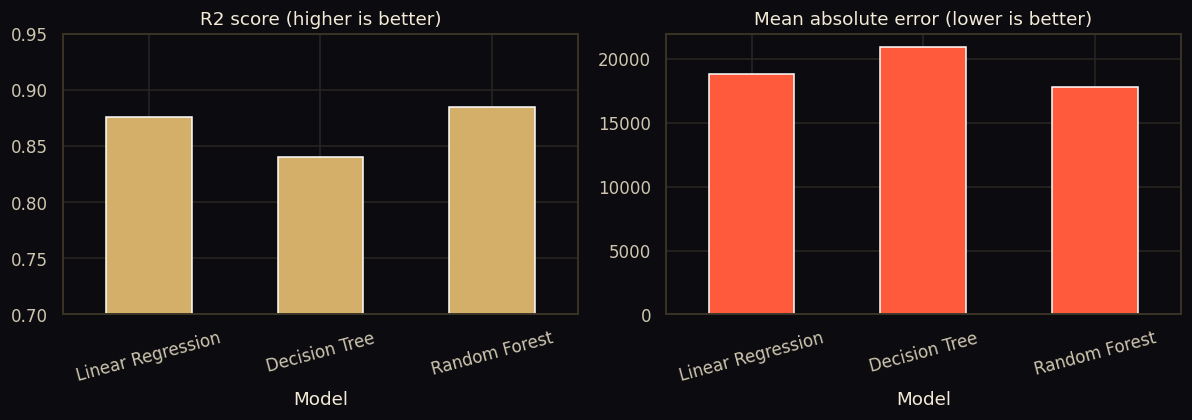

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
results["R2 (test)"].plot.bar(ax=ax[0], color=GOLD, rot=15); ax[0].set_title("R2 score (higher is better)"); ax[0].set_ylim(0.7, 0.95)
results["MAE ($)"].plot.bar(ax=ax[1], color="#ff5a3c", rot=15); ax[1].set_title("Mean absolute error (lower is better)")
plt.tight_layout(); plt.show()

Linear Regression and Random Forest reach almost the same R2, but **Random Forest has the lowest average error** and captures non-linear effects (for example the premium on high quality homes), so it is our production model.

### 5.2 Hyperparameter tuning (GridSearchCV)

In [18]:
grid = {"model__n_estimators": [100, 150], "model__max_depth": [12, 16], "model__min_samples_leaf": [2, 4]}
search = GridSearchCV(make_pipe(RandomForestRegressor(n_jobs=-1, random_state=42)), grid, cv=3, scoring="r2", n_jobs=1)
search.fit(Xtr, ytr)
print("Best parameters:", search.best_params_)
print("Best CV R2:", round(search.best_score_, 4))

Best parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 2, 'model__n_estimators': 150}
Best CV R2: 0.8455


In [19]:
best = search.best_estimator_
pred, true = np.expm1(best.predict(Xte)), np.expm1(yte)
print(f"Tuned Random Forest -> R2: {r2_score(true, pred):.3f} | MAE: ${mean_absolute_error(true, pred):,.0f} | RMSE: ${np.sqrt(mean_squared_error(true, pred)):,.0f}")

Tuned Random Forest -> R2: 0.884 | MAE: $17,811 | RMSE: $25,261


### 5.3 Evaluation plots

78% of test predictions are within 15% of the actual price


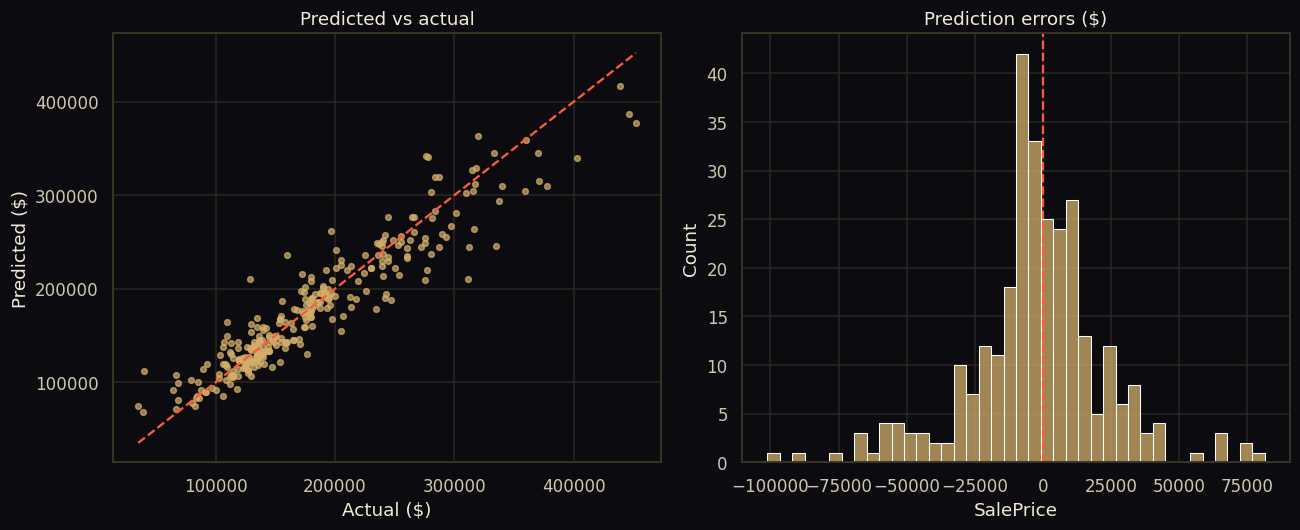

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(true, pred, s=14, color=GOLD, alpha=.7); lim = [true.min(), true.max()]
ax[0].plot(lim, lim, "--", color="#ff5a3c"); ax[0].set_title("Predicted vs actual"); ax[0].set_xlabel("Actual ($)"); ax[0].set_ylabel("Predicted ($)")
sns.histplot(pred - true, bins=40, color=GOLD, ax=ax[1]); ax[1].set_title("Prediction errors ($)"); ax[1].axvline(0, color="#ff5a3c", ls="--")
plt.tight_layout(); plt.show()
within = np.mean(np.abs(pred - true) / true < 0.15) * 100
print(f"{within:.0f}% of test predictions are within 15% of the actual price")

### 5.4 Feature importance

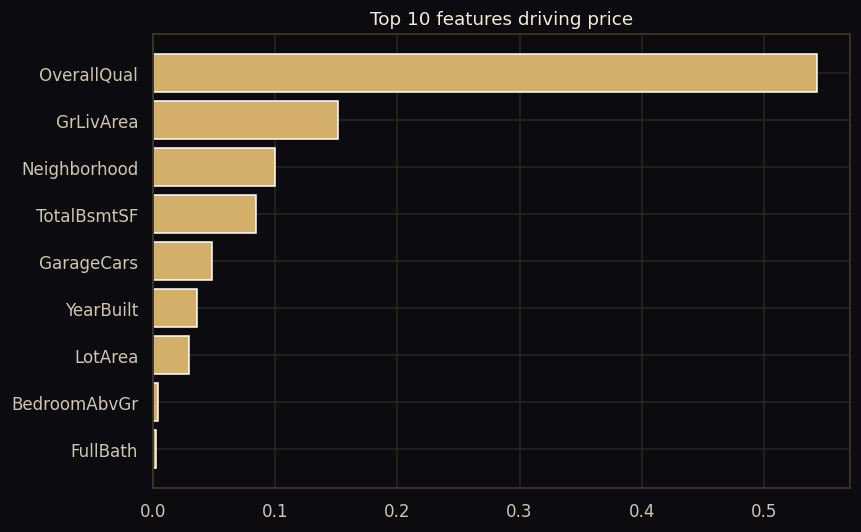

In [21]:
names = list(best.named_steps["prep"].get_feature_names_out())
imp = pd.Series(best.named_steps["model"].feature_importances_, index=names)
imp.index = [n.replace("nb__Neighborhood", "Neighborhood").replace("remainder__", "") for n in imp.index]
imp = imp.sort_values(ascending=False).head(10)[::-1]
plt.figure(figsize=(8, 5)); plt.barh(imp.index, imp.values, color=GOLD); plt.title("Top 10 features driving price")
plt.tight_layout(); plt.show()

### 5.5 Save the trained model

In [22]:
out = ROOT / "models" / "price_model_notebook.joblib"
joblib.dump(best, out, compress=5)
print("Saved:", out.name, "|", round(out.stat().st_size / 1024), "KB")

Saved: price_model_notebook.joblib | 1884 KB


In [23]:
# Load it back and predict a single new home
model = joblib.load(out)
home = pd.DataFrame([{"GrLivArea": 1710, "BedroomAbvGr": 3, "FullBath": 2, "OverallQual": 7, "YearBuilt": 2003,
                      "GarageCars": 2, "TotalBsmtSF": 856, "LotArea": 8450, "Neighborhood": "CollgCr"}])
print(f"Estimated price: ${np.expm1(model.predict(home)[0]):,.0f}")

Estimated price: $197,189


## 6. Property Recommendation System
The recommender filters by **budget, location and bedrooms**, then scores each home on budget fit, **value versus the AI fair-value estimate**, quality and user preferences. Every result comes with a plain-language explanation.

In [24]:
props = df.reset_index(drop=True).copy()
props["AIPrice"] = np.expm1(best.predict(props[FEATURES_NUM + FEATURES_CAT]))
props["ValueGap"] = (props["AIPrice"] - props["SalePrice"]) / props["AIPrice"]

def recommend(budget, neighborhoods=None, min_bedrooms=1, prefer_garage=False, prefer_new=False, top=3):
    d = props[(props.SalePrice <= budget) & (props.BedroomAbvGr >= min_bedrooms)]
    if neighborhoods: d = d[d.Neighborhood.isin(neighborhoods)]
    util = (1 - (budget - d.SalePrice).abs() / budget).clip(0, 1)
    score = 0.3*util + 0.3*(d.ValueGap.clip(-.2, .3) + .2)/.5 + 0.2*d.OverallQual/10 + 0.2*(d.GrLivArea/d.GrLivArea.max())
    if prefer_garage: score += 0.1*(d.GarageCars >= 2)
    if prefer_new: score += 0.1*(d.YearBuilt >= 2000)
    out = []
    for r in d.assign(score=score).sort_values("score", ascending=False).head(top).itertuples():
        why = [f"${budget - r.SalePrice:,.0f} under budget", f"{r.ValueGap*100:+.0f}% vs AI fair value (${r.AIPrice:,.0f})",
               f"{int(r.BedroomAbvGr)} bed, quality {int(r.OverallQual)}/10, built {int(r.YearBuilt)}"]
        out.append({"Neighborhood": r.Neighborhood, "Price": f"${r.SalePrice:,.0f}", "Why recommended": "; ".join(why)})
    return pd.DataFrame(out)

recommend(250000, ["CollgCr", "Somerst", "Gilbert"], min_bedrooms=3, prefer_garage=True, prefer_new=True)

,Neighborhood,Price,Why recommended
0,CollgCr,"$228,500","$21,500 under budget; +10% vs AI fair value ($..."
1,CollgCr,"$245,350","$4,650 under budget; +9% vs AI fair value ($26..."
2,CollgCr,"$237,000","$13,000 under budget; +4% vs AI fair value ($2..."


## 7. RAG: Knowledge Assistant over Property Documents
The assistant retrieves the most relevant passages from four real estate documents (buying guide, legal process, investment tips, area information) and the LLM writes an answer **grounded in those passages with citations**. Here we demonstrate the retrieval part with TF-IDF and cosine similarity.

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

chunks = []
for f in sorted((ROOT / "docs").glob("*.md")):
    section, buf = f.stem, []
    for line in f.read_text().splitlines():
        if line.startswith("#"):
            if buf: chunks.append((f.stem, section, " ".join(buf)))
            section, buf = line.lstrip("# ").strip(), []
        elif line.strip(): buf.append(line.strip())
    if buf: chunks.append((f.stem, section, " ".join(buf)))
vec = TfidfVectorizer(ngram_range=(1, 2), stop_words="english", sublinear_tf=True)
matrix = vec.fit_transform([f"{s} {t}" for _, s, t in chunks])
print(f"{len(chunks)} passages indexed from {len(set(c[0] for c in chunks))} documents")

def retrieve(question, k=2):
    sims = cosine_similarity(vec.transform([question]), matrix).ravel()
    return [(chunks[i][0], chunks[i][1], round(float(sims[i]), 3), chunks[i][2][:160] + "...") for i in sims.argsort()[::-1][:k]]

for q in ["How much down payment does an FHA loan need?", "What is the transfer tax in Iowa?", "How do I calculate cap rate?"]:
    print("\nQ:", q)
    for doc, sec, score, text in retrieve(q, 1): print(f"   -> {doc} / {sec} (score {score})\n      {text}")

65 passages indexed from 4 documents

Q: How much down payment does an FHA loan need?
   -> property_buying_guide / 2. Down Payment and Loan Types (score 0.152)
      A 20% down payment avoids private mortgage insurance (PMI) on a conventional loan, but it is not required. Common options include: - **Conventional loans:** oft...

Q: What is the transfer tax in Iowa?
   -> legal_registration_guide / 8. Taxes and Fees at Closing (score 0.25)
      - **Real estate transfer tax:** Iowa charges a transfer tax calculated per $500 of value, with the first $500 exempt. Confirm the current rate with the county r...

Q: How do I calculate cap rate?
   -> investment_tips / 3. A Worked Example (score 0.192)
      Suppose you buy a house for $200,000 that rents for $1,700 per month. - Gross annual rent: $20,400. After a 6% vacancy allowance: about $19,176. - Operating exp...


## 8. Conclusions

- **Data:** after cleaning, 1,458 homes with no missing values; price is right-skewed so a log target works best.
- **Drivers of price:** overall quality, living area, garage, basement, year built and neighborhood.
- **Model:** the tuned Random Forest explains about 88% of price variance with an average error of roughly $18,000, and about 78% of test predictions fall within 15% of the real price.
- **Product:** the same model, recommender and RAG retriever are exposed through a FastAPI backend with a premium web interface, a Groq-powered AI assistant and a document knowledge base.

**Limitations:** the data covers one city and the years 2006-2010, so estimates are educational and not a substitute for a professional appraisal.